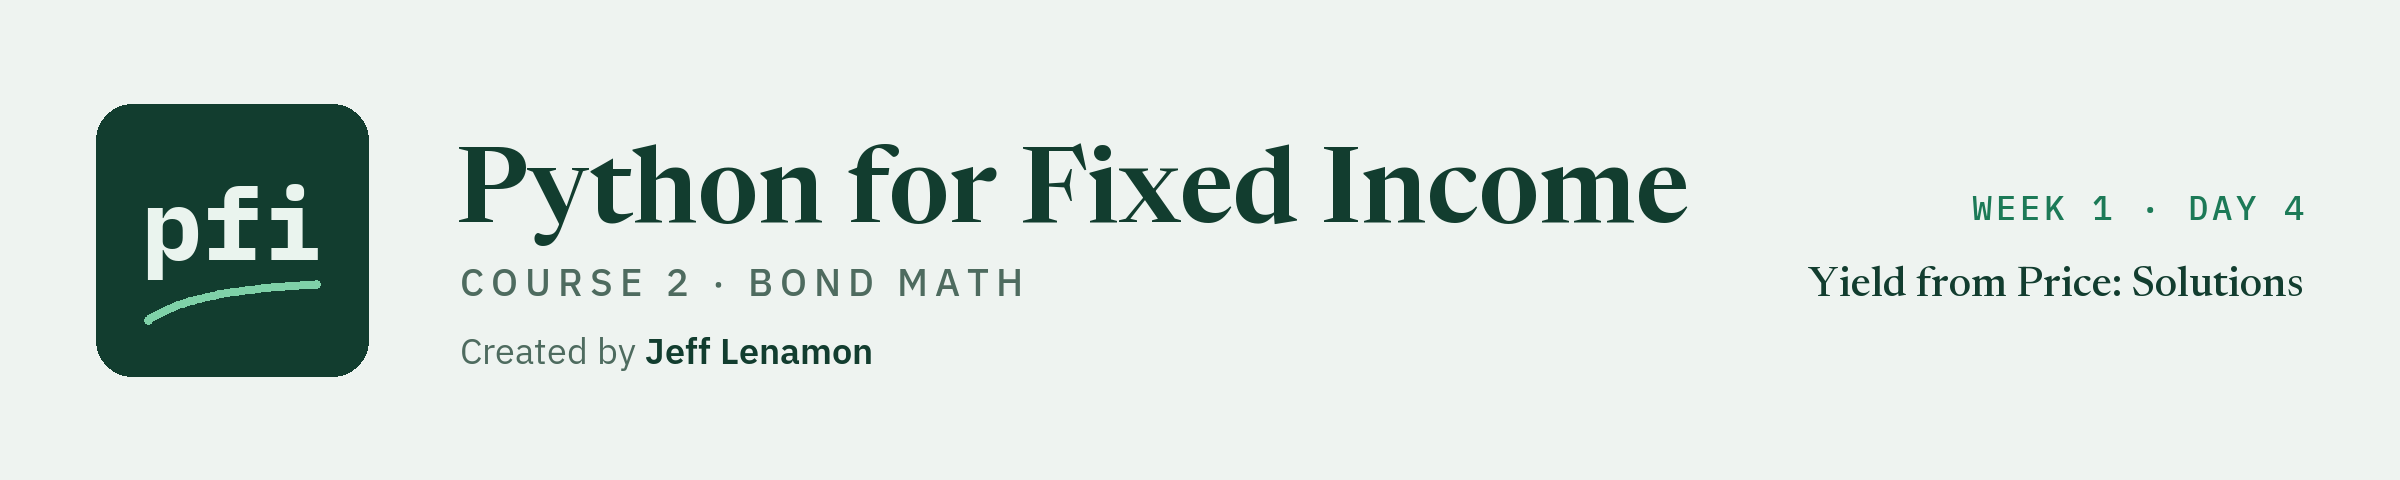

# Yield from Price: Solutions

Week 1, Day 4. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week1/day4/04_yield_from_price_solutions.ipynb)

This notebook stands on its own. Its setup writes `bondmath.py` and `test_bondmath.py` as they stand at the end of today, so the exercises can be run without the lesson.

Q. Set up today's work folder.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_04_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_04_vmrhki9r, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the end of today.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price']


## Exercises

The exercises use the second set of four bonds from days 1 to 3, now quoted on price on 30 September 2026 like the first four. The issuers and the quotes are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on with f-strings. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds with their quotes and defines `check`, a small function that marks your answers.

In [5]:
exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30'],
    "years": [4, 2, 6, 8],
    # the quoted price, per 100 of face
    "quote": [99.5, 100.25, 98.375, 97.625],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,years,quote
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,4,99.500
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,2,100.250
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,6,98.375
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,8,97.625


### Exercise 1

Q. With `bondmath.yield_from_price`, find the yield of each exercise bond from its quote. Store Osmere's yield, in percent and unrounded, in **ex1_osmere**, and the ticker of the bond with the highest yield in **ex1_highest**.

In [6]:
exercise_bonds["yield_pct"] = [
    bondmath.yield_from_price(c, p, t)
    for c, p, t in zip(exercise_bonds["coupon_pct"], exercise_bonds["quote"], exercise_bonds["years"])
]
print(exercise_bonds[["ticker", "coupon_pct", "quote", "yield_pct"]].round(4))

ex1_osmere = exercise_bonds.loc[exercise_bonds["ticker"] == "OSMC", "yield_pct"].iloc[0]
# idxmax gives the row label of the largest value
ex1_highest = exercise_bonds.loc[exercise_bonds["yield_pct"].idxmax(), "ticker"]

print(f"Osmere at 98.375 yields {ex1_osmere:.4f} percent. Highest yield: {ex1_highest}")

  ticker  coupon_pct    quote  yield_pct
0   OSTV       5.625   99.500     5.7668
1   TRNW       4.375  100.250     4.2433
2   OSMC       5.000   98.375     5.3199
3   CLDB       8.250   97.625     8.6677
Osmere at 98.375 yields 5.3199 percent. Highest yield: CLDB


* Osmere at 98.375 yields 5.3199 percent, above its 5 percent coupon because it is quoted below 100. Tarnwick, the one quote above 100, yields 4.2433, below its 4.375 coupon.
* Calderby yields the most, 8.6677 percent.
* Excel agrees: `=RATE(2*6,5/2,-98.375,100)*2` returns 0.053199095567824824, and `=YIELD(DATE(2026,9,30),DATE(2032,9,30),5/100,98.375,100,2,0)` returns 0.05319909556782486.

In [7]:
check("Exercise 1 Osmere yield", ex1_osmere, 5.319909556762923)
check("Exercise 1 highest yield", ex1_highest, "CLDB")

Exercise 1 Osmere yield: correct
Exercise 1 highest yield: correct


### Exercise 2

Q. Suppose Halvering's quote rises one point, from 97.75 to 98.75, and Pellwick's rises one point, from 100.875 to 101.875. By how many basis points does each yield change? Store the two changes, unrounded and negative for a fall, in **ex2_halvering_bp** and **ex2_pellwick_bp**, and in **ex2_larger** the ticker whose yield moves more, `"HLVF"` or `"PLWK"`. The quotes are what-ifs.

In [8]:
# a yield change in basis points is the change in percent times 100
ex2_halvering_bp = (bondmath.yield_from_price(7.5, 98.75, 10) - bondmath.yield_from_price(7.5, 97.75, 10)) * 100
ex2_pellwick_bp = (bondmath.yield_from_price(4.75, 101.875, 3) - bondmath.yield_from_price(4.75, 100.875, 3)) * 100
ex2_larger = "HLVF" if abs(ex2_halvering_bp) > abs(ex2_pellwick_bp) else "PLWK"

print(f"One point up in price: Halvering {ex2_halvering_bp:+.2f} bp, Pellwick {ex2_pellwick_bp:+.2f} bp")
print(f"The yield that moves more: {ex2_larger}")

One point up in price: Halvering -14.72 bp, Pellwick -35.57 bp
The yield that moves more: PLWK


* Halvering's yield falls 14.72 basis points, Pellwick's 35.57. The same point of price moves the 3-year bond's yield more than twice as far.
* It is day 3 seen from the other side. A long bond's price moves a lot for a small change in yield, so a point of price is only a small change in its yield. A short bond's price moves little, so the same point is a large change in its yield.

In [9]:
check("Exercise 2 Halvering change", ex2_halvering_bp, -14.724150213623943)
check("Exercise 2 Pellwick change", ex2_pellwick_bp, -35.56528486387833)
check("Exercise 2 larger move", ex2_larger, "PLWK")

Exercise 2 Halvering change: correct
Exercise 2 Pellwick change: correct
Exercise 2 larger move: correct


### Exercise 3

Q. Add a function to your module. `yield_change_bp(old_yield_pct, new_yield_pct)` returns the change from one yield to another in basis points, positive for a rise. Write the docstring first: units, convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_yield_change_bp_cases`, with two cases you can check by hand, and a check that Excel's `RATE` and `YIELD` rows for the same quotes (`tvm_rows("RATE")` and `tvm_rows("YIELD")`) are less than 0.0001 basis points apart by your function. Run pytest, and store the change from Quorvane's issue yield, 5.40 percent, to the yield of today's quote, 99.125, from `bondmath.yield_change_bp`, in **ex3_change**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [10]:
%%writefile -a bondmath.py


def yield_change_bp(old_yield_pct: float, new_yield_pct: float) -> float:
    """The change from one yield to another, in basis points.

    Units: yields in percent. Returns basis points: 1 percentage point is 100 basis points.
    Convention: a rise is positive. change = (new_yield_pct - old_yield_pct) x 100.
    Excel: =(new-old)*100, with both yields in percent
    """
    # percentage points times 100 is basis points
    return (new_yield_pct - old_yield_pct) * 100

Appending to bondmath.py


In [11]:
%%writefile -a test_bondmath.py


def test_yield_change_bp_cases():
    # hand cases: 5.00 to 5.25 percent is 25 bp up; 6.10 to 6.00 percent is 10 bp down
    assert bondmath.yield_change_bp(5.0, 5.25) == pytest.approx(25.0)
    assert bondmath.yield_change_bp(6.1, 6.0) == pytest.approx(-10.0)
    # Excel's RATE and YIELD for the same eight quotes: the two routes are far less than 0.0001 bp apart
    yield_rows = tvm_rows("YIELD")
    rate_rows = [row for row in tvm_rows("RATE") if (row["coupon_pct"], row["price"]) in
                 [(y["coupon_pct"], y["price"]) for y in yield_rows]]
    assert len(rate_rows) == len(yield_rows)
    for rate_row, yield_row in zip(rate_rows, yield_rows):
        change = bondmath.yield_change_bp(float(rate_row["excel_value"]) * 100, float(yield_row["excel_value"]) * 100)
        assert abs(change) < 1e-4, yield_row["case_id"]

Appending to test_bondmath.py


In [12]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

............                                                             [100%]
12 passed in 0.05s



In [13]:
# the file changed, so reload before calling the new function
importlib.reload(bondmath)

quote_yield_pct = bondmath.yield_from_price(5.25, 99.125, 5)
ex3_change = bondmath.yield_change_bp(5.40, quote_yield_pct)

print(f"Quorvane, 5.40 percent at issue to {quote_yield_pct:.4f} percent at 99.125: {ex3_change:+.2f} bp")

Quorvane, 5.40 percent at issue to 5.4523 percent at 99.125: +5.23 bp


* `12 passed`: the 11 tests of the lesson and the new one.
* Quorvane's quote of 99.125 is 5.23 basis points above the 5.40 percent it was issued at: a lower price, a higher yield.
* The test pairs each `RATE` row with the `YIELD` row for the same coupon and price, so it does not depend on where the rows sit in the file.
* In Excel, with the old yield in B1 and the new in B2, both in percent: `=(B2-B1)*100`.

In [14]:
check("Exercise 3 Quorvane yield change", ex3_change, 5.229650329247271)

Exercise 3 Quorvane yield change: correct


### Exercise 4: AI check

You ask an AI assistant to write `yield_from_price` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Yield of a bullet bond on a coupon date, from its price, by bisection.

Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
Raises ValueError if the price is outside the prices at those two yields.
Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

* The bug: the search runs on the rate per period, a half-year's rate for a semiannual bond, and the function returns that rate as it is. The docstring promises the annual yield, compounded `frequency` times a year. Quorvane at 99.125 came back as 2.7261 instead of 5.4523: exactly half.
* The test caught it on the first `RATE` row, `tvm_rate_01`: 2.821133 against Excel's 5.642266.
* One row would have passed: `tvm_rate_06`, the only bond that pays once a year. With a frequency of 1 the rate per period is the annual rate, so the bug is invisible there. A test on annual bonds alone would have missed it.
* The round-trip test of section 4.7 would also catch this one, because `price_from_yield` is right: the per-period yield, priced as an annual yield, does not give back the price.
* The fix, in the cell below: multiply the per-period rate by the frequency before returning it.

In [15]:
def assistant_yield_from_price(coupon_pct, price, years, frequency=2):
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
Raises ValueError if the price is outside the prices at those two yields.
Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # search the rate per period, in percent: the annual bracket divided by the frequency
    low_pct, high_pct = -5.0 / frequency, 100.0 / frequency
    highest_price = bondmath.price_from_yield(coupon_pct, low_pct * frequency, years, frequency)
    lowest_price = bondmath.price_from_yield(coupon_pct, high_pct * frequency, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        # price_from_yield takes the annual yield, so the rate per period times the frequency
        if bondmath.price_from_yield(coupon_pct, mid_pct * frequency, years, frequency) > price:
            low_pct = mid_pct
        else:
            high_pct = mid_pct
    # the fix: the search found the rate per period; the docstring promises the annual yield
    return (low_pct + high_pct) / 2 * frequency

In [16]:
# the test, written from Excel's reference rows before the code is trusted
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
rate_rows = tvm[tvm["function"] == "RATE"]

# RATE times the frequency is the annual yield as a decimal, so times 100 for percent
for row in rate_rows.itertuples():
    result = assistant_yield_from_price(row.coupon_pct, row.price, row.years, int(row.frequency))
    assert abs(result - row.excel_value * 100) < 1e-6, f"{row.case_id}: {result:.6f} against Excel's {row.excel_value * 100:.6f}"

print(f"All {len(rate_rows)} RATE rows match Excel")

All 18 RATE rows match Excel


In [17]:
ex4_quorvane = assistant_yield_from_price(5.25, 99.125, 5)
ex4_rows = len(rate_rows)

print(f"Quorvane at 99.125 from the fixed function: {ex4_quorvane:.4f} percent")
print(f"RATE rows checked: {ex4_rows}")

Quorvane at 99.125 from the fixed function: 5.4523 percent
RATE rows checked: 18


* 5.4523, the yield from section 4.5, and all 18 rows match. The fixed function now does what its docstring says: the annual yield, in percent.

In [18]:
check("Exercise 4 Quorvane yield", ex4_quorvane, 5.452296503292473)
check("Exercise 4 rows checked", ex4_rows, 18)

Exercise 4 Quorvane yield: correct
Exercise 4 rows checked: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```